Model Hyparameters Config

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

# settings
seed = 42
model = 'llava-v1.5'
# model = 'minigpt4'
# model = "instructblip"
# model = "qwen-vl"
sample = False
temperature = -1
top_p = None
num_beams = 1
max_new_tokens = 512

#hyparams
use_jsd = 1
alpha = 0.6
threshold_top_p = 0.9
threshold_top_k = 20
early_exit_layers=[i for i in range(20, 29, 1)]

In [2]:
import argparse
import json
import random
import numpy as np
import torch
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from constants import INSTRUCTION_TEMPLATE, SYSTEM_MESSAGE
from eval_data_loader import COCODataSet
from llava.utils import disable_torch_init
from model_loader import ModelLoader
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from transformers import set_seed
from chair import CHAIR
import pickle

/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
label_path = '/data1/zhr/datasets/coco2014/annotations/captions_val2014.json'
with open(label_path, 'r') as f:
    label_data = json.load(f)
img_cap = label_data['annotations']

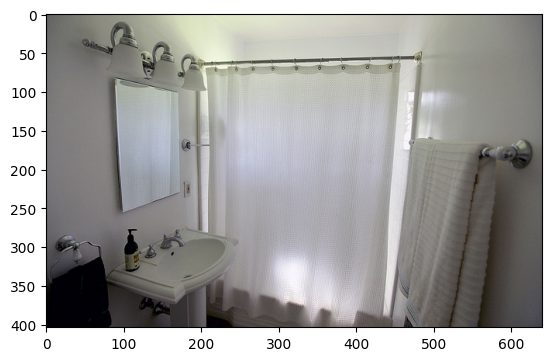

Image ID: 123843
Caption:
 A bathroom with a mirror, lighting and bathtub with shower combo


In [4]:
idx = 1000
image_id = img_cap[idx]['image_id']
image_path = "/data1/zhr/datasets/coco2014/val2014/" + "COCO_val2014_"+str(image_id).zfill(12) + ".jpg"
image = Image.open(image_path).convert("RGB")
caption = img_cap[idx]['caption']
plt.imshow(image)
plt.show()
print("Image ID:", image_id)
print("Caption:\n", caption)

load model

In [5]:
set_seed(seed)
disable_torch_init()

model_loader = ModelLoader(model)

Loading LLava


/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading checkpoint shards: 100%|██████████| 2/2 [00:10<00:00,  5.02s/it]


In [22]:
tokenizer = model_loader.tokenizer

template = INSTRUCTION_TEMPLATE[model]

# query = "Please help me describe the image in detail."
query = "Describe this image in detail."
# query = "Describe this image in detail in English."
# query = "Please help me describe the image in detail in English"
# query = "Is there a snowboard in the image?" # label:yes
# query = "Is there a book in the image?" # label:no
prefix = ""
# prefix=" The image features a group of people gathered on a boat, enjoying a day of water sports. There are several individuals on the boat, with some of them wearing life jackets and holding onto ropes. A man is riding a "
# prefix = "The image shows a group of people waiting in line at an airport baggage claim area,"
# prefix=" The image features a small bathroom with a white toilet and a "

# prefix = " The image showcases a spacious and well-decorated living room with a large couch and a coffee table. The couch is positioned in the center of the room, with a chair placed nearby. The coffee table is adorned with a "
# prefix = " Additionally, there are two "
# prefix = " A bench is visible in the background, and a "

if model == "llava-v1.5":
    model_loader.vlm_model.config.image_aspect_ratio = None

questions, kwargs = model_loader.prepare_inputs_for_model(template, query, image_path, prefix)
label_ids = tokenizer([caption], return_tensors="pt").to('cuda').input_ids[:,1:]
# kwargs['label_ids'] = label_ids

In [23]:
print(label_ids.shape)

torch.Size([1, 18])


In [24]:
# label_ids = tokenizer([caption], return_tensors="pt").to('cuda')

In [25]:
# print(label_ids)

In [26]:
label_word = [tokenizer.decode(t.cpu()) for t in label_ids]
print(label_word)

['A bathroom with a mirror, lighting and bathtub with shower combo']


In [27]:
print(questions)

A chat between a curious human and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the human's questions. USER: <image>
Describe this image in detail. ASSISTANT:


In [28]:
print(label_ids.shape)

torch.Size([1, 18])


In [29]:
# baseline
# with torch.inference_mode():
#     output_ids = model_loader.llm_model.generate(
#         do_sample=sample,
#         temperature=temperature,
#         top_p=top_p,
#         num_beams=num_beams,
#         max_new_tokens=max_new_tokens,
#         use_cache=True,
#         **kwargs,
#     )

# outputs = model_loader.decode(output_ids)[0]

In [30]:
# use_jsd= 2
# alpha = 10
# beta = 0
# early_exit_layers=[i for i in range(20, 29, 1)]
# ci_min_val = 1000
# ci_min_alpha = -1
# min_alpha_list = []

# for alpha in tqdm(range(1,20)):
#     with torch.inference_mode():
#         output_dict, uncond_output_dict = model_loader.llm_model.generate(
#             do_sample=sample,
#             temperature=temperature,
#             top_p=top_p,
#             num_beams=num_beams,
#             max_new_tokens=512,
#             use_cache=True,
#             use_jsd=use_jsd,
#             alpha = alpha,
#             beta = beta,
#             threshold_top_p=threshold_top_p, 
#             threshold_top_k=threshold_top_k,
#             early_exit_layers=early_exit_layers,
#             return_dict=True,
#             return_dict_in_generate=True,
#             output_hidden_states=True,
#             output_scores=True,
#             **kwargs,
#         )

#     output_ids = output_dict.sequences
#     outputs = model_loader.decode(output_ids)[0]
#     evaluator = pickle.load(open("/data1/zhr/checkpoints/chair/cache.pkl", 'rb'))
#     cap_dict = evaluator.compute_sample_chair(outputs, image_id)
#     if cap_dict["metrics"]["CHAIRi"] < ci_min_val:
#         ci_min_val = cap_dict["metrics"]["CHAIRi"]
#         ci_min_alpha = alpha
#         min_alpha_list = [alpha]
#     elif cap_dict["metrics"]["CHAIRi"] == ci_min_val:
#         min_alpha_list.append(alpha)

# print("CHAIRi: ", ci_min_val, ci_min_alpha, min_alpha_list)


In [31]:
use_jsd= 4

with torch.inference_mode():
    output_dict, uncond_output_dict = model_loader.llm_model.generate(
        do_sample=sample,
        temperature=temperature,
        top_p=top_p,
        num_beams=num_beams,
        max_new_tokens=512,
        use_cache=True,
        use_jsd=use_jsd,
        threshold_top_p=threshold_top_p, 
        threshold_top_k=threshold_top_k,
        return_dict=True,
        return_dict_in_generate=True,
        output_hidden_states=True,
        output_scores=True,
        label_ids = label_ids,
        **kwargs,
    )

output_ids = output_dict.sequences
outputs = model_loader.decode(output_ids)[0]

In [32]:
output_word = [tokenizer.decode(t.cpu()) for t in output_ids[:, model_loader.input_ids_len:]]
print(output_word)

['A bathroom with a mirror, lighting and bathtub with shower combo']


In [33]:
# use_deco= True
# alpha = 0.6
# early_exit_layers=[i for i in range(20, 29, 1)]


# with torch.inference_mode():
#     output_dict = model_loader.llm_model.generate(
#         do_sample=sample,
#         temperature=temperature,
#         top_p=top_p,
#         num_beams=num_beams,
#         max_new_tokens=512,
#         use_cache=True,
#         use_deco=use_deco,
#         alpha = alpha,
#         threshold_top_p=threshold_top_p, 
#         threshold_top_k=threshold_top_k,
#         early_exit_layers=early_exit_layers,
#         return_dict=True,
#         return_dict_in_generate=True,
#         output_hidden_states=True,
#         output_scores=True,
#         **kwargs,
#     )

# output_ids = output_dict.sequences
# outputs = model_loader.decode(output_ids)[0]

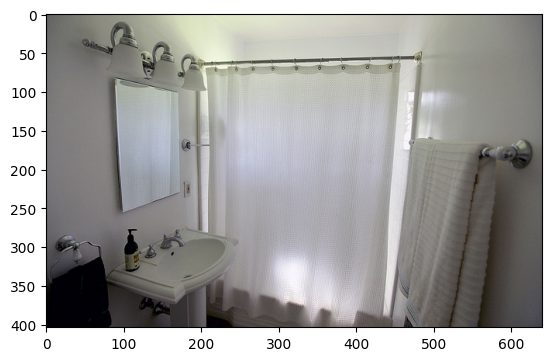

Image ID: 123843
Ours:
 A bathroom with a mirror, lighting and bathtub with shower combo


In [34]:
plt.imshow(image)
plt.show()
print("Image ID:", image_id)
print("Ours:\n", outputs)

In [35]:
# evaluator = pickle.load(open("/data1/zhr/checkpoints/chair/cache.pkl", 'rb'))
# cap_dict = evaluator.compute_sample_chair(outputs, image_id)
# print(cap_dict)

In [36]:
if kwargs.get("input_ids", None) is not None:
    input_token_len = kwargs["input_ids"].shape[1]
else:
    input_token_len = 0

target_word = "coconuts    "
start_idx = 6
outputs_tokens = output_ids[0, input_token_len:]
# words = tokenizer.decode(outputs_tokens[start_idx:start_idx+50]).encode("unicode_escape").decode()
for idx, token in enumerate(outputs_tokens[start_idx:]):
    word = tokenizer.decode(token)
    if word == target_word[:len(word)] and len(word) > 0:
        print(start_idx+idx, word, tokenizer.decode(outputs_tokens[start_idx+idx:start_idx+idx+10]))
        break


In [51]:
token_idx = 0
# token_idx = 16
threshold_top_k = 20
layer_logits = []
uncond_layer_logits = []

hidden_states = output_dict.hidden_states[token_idx]
uncond_hidden_states = uncond_output_dict.hidden_states[token_idx]

if model == "qwen-vl":
    layer_norm = model_loader.llm_model.transformer.ln_f
else:
    layer_norm = model_loader.llm_model.model.norm

for layer_id in range(0, 33):
    if layer_id != 32:
        layer_output = layer_norm(hidden_states[layer_id])
        uncond_layer_output = layer_norm(uncond_hidden_states[layer_id])
    else:
        layer_output = hidden_states[layer_id].clone()
        uncond_layer_output = uncond_hidden_states[layer_id].clone()
    logits = model_loader.llm_model.lm_head(layer_output)[:,-1,:]
    uncond_logits = model_loader.llm_model.lm_head(uncond_layer_output)[:,-1,:]
    layer_logits.append(logits)
    uncond_layer_logits.append(uncond_logits)

stacked_layer_logits = torch.stack(layer_logits, dim=0) # shape: (num_layers, batch_size, vocab_size)
stacked_uncond_layer_logits = torch.stack(uncond_layer_logits, dim=0)


layer_softmax = F.softmax(stacked_layer_logits, dim=-1) # shape: (num_layers, batch_size, vocab_size)
uncond_layer_softmax = F.softmax(stacked_uncond_layer_logits, dim=-1)

layer_log_softmax = F.log_softmax(stacked_layer_logits, dim=-1)
uncond_layer_log_softmax =F.log_softmax(stacked_uncond_layer_logits, dim=-1)

final_layer_softmax = layer_softmax[-1, :, :]
final_layer_log_softmax = layer_log_softmax[-1, :, :]

probs = layer_softmax.squeeze()
uncond_probs = uncond_layer_softmax.squeeze()
# probs = layer_log_softmax.squeeze()
# uncond_probs = uncond_layer_log_softmax.squeeze()

In [52]:
candidate_tokens_probs, top_k_candidate_tokens_ids = torch.topk(probs[-1], dim=-1, k=threshold_top_k)

candidate_tokens_cumulative_probs = candidate_tokens_probs.cumsum(dim=-1).float()
candidate_tokens_indices = torch.searchsorted(candidate_tokens_cumulative_probs, threshold_top_p, right=False)
candidate_tokens_cutoff_idx = torch.min(candidate_tokens_indices + 1, torch.tensor(threshold_top_k))   

candidate_tokens_ids = top_k_candidate_tokens_ids[:candidate_tokens_cutoff_idx]

label_token_id = label_ids[:,token_idx]
label_word = [tokenizer.decode(label_token_id.cpu())]

print('label:', label_word)

tokens_ids = candidate_tokens_ids.clone().detach()
if label_token_id not in candidate_tokens_ids:
    tokens_ids = torch.cat([label_token_id, tokens_ids])

print(tokens_ids)


top_k_words = [tokenizer.decode(t.cpu()) for t in top_k_candidate_tokens_ids]
top_p_words = [tokenizer.decode(t.cpu()) for t in candidate_tokens_ids]
words = [tokenizer.decode(t.cpu()) for t in tokens_ids]

final_softmax_score = F.softmax(output_dict.scores[token_idx][0], dim=-1)
final_tokens_probs, final_tokens_ids = torch.topk(final_softmax_score, dim=-1, k=threshold_top_k)

final_words = [tokenizer.decode(t.cpu()) for t in final_tokens_ids]

print("top_k_candidate_tokens\n", top_k_words)
print(candidate_tokens_probs)

print("top_p_candidate_tokens\n", top_p_words)
print(candidate_tokens_probs[:candidate_tokens_cutoff_idx])

# jsd 2
# print("next token logits\n", output_dict.next_token_scores[token_idx][...,candidate_tokens_ids])
# print("next token uncond logits\n", uncond_output_dict.scores[token_idx][...,candidate_tokens_ids])
# print("target layer logits\n", output_dict.target_layer_scores[token_idx][...,candidate_tokens_ids])
# print("uncond target layer logits\n", uncond_output_dict.target_layer_scores[token_idx][...,candidate_tokens_ids])
# print("Target Layer idx: ", output_dict.target_layers[token_idx])
# print("target layer max probs: ", output_dict.target_max_probs[token_idx])
# print("uncond target layer max probs: ", uncond_output_dict.target_max_probs[token_idx])
# print("final logits\n", output_dict.final_scores[token_idx][...,candidate_tokens_ids])


# jsd 4
# print("jsd_probs: ", output_dict.jsd_probs[token_idx])
# print("deco_probs: ", output_dict.deco_probs[token_idx])
# print("jsd_layer_idx: ", output_dict.jsd_layer_idx[token_idx])
# print("deco_layer_idx: ", output_dict.deco_layer_idx[token_idx])
# print("jsd_val: ", output_dict.jsd_val[token_idx])


print("final_tokens\n", final_words)
print(final_tokens_probs)

label: ['A']
top_k_candidate_tokens
 ['The', 'This', 'In', 'A', 'Inside', 'It', 'An', 'There', 'Within', 'As', 'On', 'I', 'At', 'Set', 'With', 'Enter', 'The', 'From', 'Here', 'Fe']
tensor([9.5850e-01, 2.1851e-02, 1.7014e-02, 1.8215e-03, 2.7514e-04, 1.4949e-04,
        4.2856e-05, 3.2365e-05, 2.1517e-05, 2.0266e-05, 1.5736e-05, 1.3053e-05,
        9.0003e-06, 7.9274e-06, 6.9737e-06, 6.4969e-06, 5.9605e-06, 5.9605e-06,
        5.6028e-06, 4.7088e-06], device='cuda:0', dtype=torch.float16,
       grad_fn=<TopkBackward0>)
top_p_candidate_tokens
 ['The']
tensor([0.9585], device='cuda:0', dtype=torch.float16,
       grad_fn=<SliceBackward0>)
final_tokens
 ['The', 'This', 'In', 'A', 'Inside', 'It', 'An', 'There', 'Within', 'As', 'On', 'I', 'At', 'Set', 'With', 'Enter', 'The', 'From', 'Here', 'Fe']
tensor([9.5854e-01, 2.1849e-02, 1.7016e-02, 1.8217e-03, 2.7504e-04, 1.4954e-04,
        4.2843e-05, 3.2340e-05, 2.1543e-05, 2.0238e-05, 1.5761e-05, 1.3066e-05,
        8.9804e-06, 7.9251e-06, 6.9939

In [53]:
# cross layer JSD
# M = 0.5 * (layer_softmax[...,label_token_id] + uncond_layer_softmax[...,label_token_id])

# kl1 = F.kl_div(layer_log_softmax[...,label_token_id], M, reduction='none').mean(-1) # shape: (num_layers, batch_size)
# kl2 = F.kl_div(uncond_layer_log_softmax[...,label_token_id], M, reduction='none').mean(-1)
# js_divs = 0.5 * (kl1 + kl2)
# cross_layer_js_divs = js_divs.mean(-1) # shape: (num_layers,)

In [54]:
# cross layer JSD
M = 0.5 * (layer_softmax[...,candidate_tokens_ids] + uncond_layer_softmax[...,candidate_tokens_ids])

kl1 = F.kl_div(layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1) # shape: (num_layers, batch_size)
kl2 = F.kl_div(uncond_layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1)
js_divs = 0.5 * (kl1 + kl2)
cross_layer_js_divs = js_divs.mean(-1) # shape: (num_layers,)

In [55]:
# cross layer JSD
# M = 0.5 * (layer_softmax + uncond_layer_softmax)

# kl1 = F.kl_div(layer_log_softmax, M, reduction='none').mean(-1) # shape: (num_layers, batch_size)
# kl2 = F.kl_div(uncond_layer_log_softmax, M, reduction='none').mean(-1)
# js_divs = 0.5 * (kl1 + kl2)
# cross_layer_js_divs = js_divs.mean(-1) # shape: (num_layers,)

In [56]:
print(cross_layer_js_divs.shape)

torch.Size([33])


In [57]:
# print(output_dict.target_layers[token_idx])
# print(cross_layer_js_divs[output_dict.target_layers[token_idx]])

In [58]:
# next_token_logits = output_dict.next_token_scores[token_idx][...,candidate_tokens_ids]
# max_probs = output_dict.target_max_probs[token_idx]
# target_layer_logits = output_dict.target_layer_scores[token_idx][...,candidate_tokens_ids]
# uncond_target_layer_logits = uncond_output_dict.target_layer_scores[token_idx][...,candidate_tokens_ids]
# jsd_max_val = cross_layer_js_divs[output_dict.target_layers[token_idx]]
# final_token_logits = next_token_logits + alpha * max_probs * ((1+jsd_max_val)*target_layer_logits - jsd_max_val*uncond_target_layer_logits)
# print(final_token_logits)

In [59]:
print(probs[:,label_token_id].shape)

torch.Size([33, 1])


In [60]:
def pearson_correlation(x, y):
    """
    计算两个tensor变量之间的皮尔逊相关系数
    
    参数:
    x, y: tensor变量，需要具有相同的形状
    
    返回:
    皮尔逊相关系数 (标量tensor)
    """
    # 确保tensor展平为1D向量
    x = x.flatten()
    y = y.flatten()
    
    # 计算均值
    mean_x = torch.mean(x)
    mean_y = torch.mean(y)
    
    # 计算分子(协方差)
    cov_xy = torch.mean((x - mean_x) * (y - mean_y))
    
    # 计算分母(标准差的乘积)
    std_x = torch.std(x)
    std_y = torch.std(y)
    
    # 计算皮尔逊相关系数
    correlation = cov_xy / (std_x * std_y)
    
    return correlation

In [61]:
print(pearson_correlation(cross_layer_js_divs, probs[:,label_token_id]))

tensor(0.4167, device='cuda:0', dtype=torch.float16, grad_fn=<DivBackward0>)


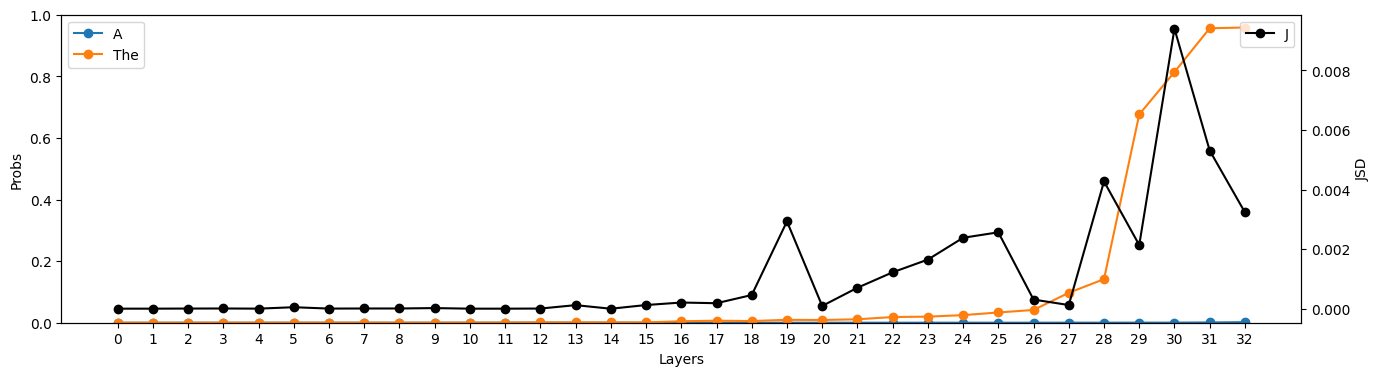

In [62]:
# candidate_tokens_early_exit_probs = probs[:,label_token_id].float()
candidate_tokens_early_exit_probs = probs[:,tokens_ids].float()
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Probs")
ax.set_xticks(range(33))
ax.set_ylim(0, 1)
ax.legend(words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs.float()

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J", loc='upper right')
# plt.savefig("jsd250910.jpg", dpi=500)
plt.show()

# print("Max JS divergence idx: ", jsd.argmax().item())
# print("Target Layer idx: ", output_dict.target_layers[token_idx])

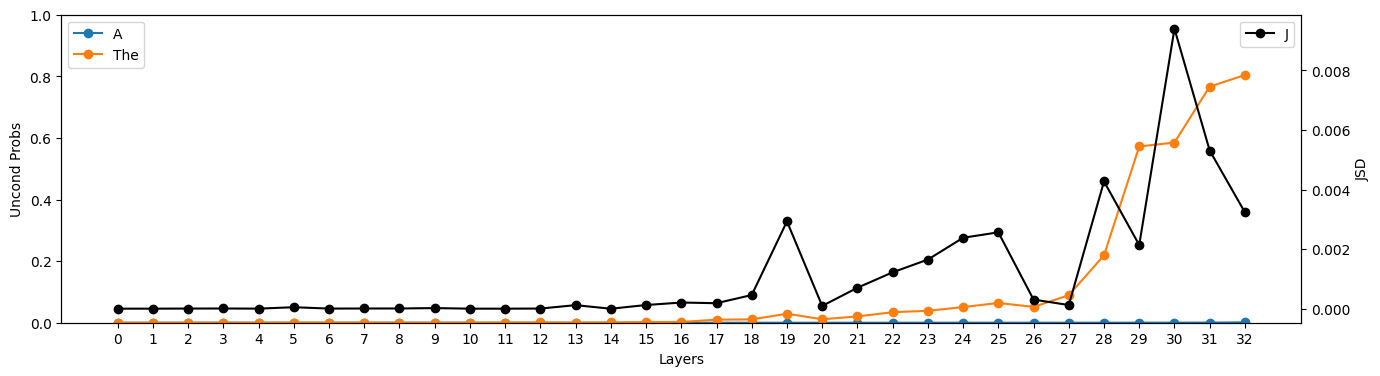

In [63]:
# uncond_candidate_tokens_early_exit_probs = uncond_probs[:,label_token_id].float()
uncond_candidate_tokens_early_exit_probs = uncond_probs[:,tokens_ids].float()
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(uncond_candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Uncond Probs")
ax.set_xticks(range(33))
ax.set_ylim(0, 1)
ax.legend(words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs.float()

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J", loc='upper right')

plt.show()

In [64]:

# stacked_var_layer_logits = stacked_layer_logits-stacked_uncond_layer_logits
# # indices_to_remove = torch.ones_like(stacked_var_layer_logits)
# # indices_to_remove[..., candidate_tokens_ids] = 0
# # indices_to_remove = indices_to_remove.bool()
# # var_layer_logits = stacked_var_layer_logits.masked_fill(indices_to_remove, -float("Inf"))
# # var_layer_softmax = F.softmax(var_layer_logits, dim=-1).squeeze()
# # var_candidate_tokens_early_exit_probs = var_layer_softmax[:,candidate_tokens_ids]
# var_candidate_tokens_early_exit_probs = stacked_var_layer_logits[...,candidate_tokens_ids].squeeze()
# fig, ax = plt.subplots(figsize=(16, 4))
# ax.plot(var_candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
# ax.set_xlabel("Layers")
# ax.set_ylabel("Var Probs")
# ax.set_xticks(range(33))
# # ax.set_ylim(0, 1)
# ax.legend(top_p_words, loc='upper left')

# # jsd = cross_layer_js_divs.max() - cross_layer_js_divs
# jsd = cross_layer_js_divs

# ax2 = ax.twinx()
# ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
# ax2.set_ylabel("JSD")
# ax2.legend("J", loc='upper right')

# plt.show()